In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

In [2]:
df = pd.read_csv('new_hr.csv')
df = df.drop(columns=['EmployeeCount','YearsInCurrentRole','YearsWithCurrManager','PercentSalaryHike','BusinessTravel','JobSatisfaction','WorkLifeBalance','Over18','EnvironmentSatisfaction','MaritalStatus','EmployeeNumber','RelationshipSatisfaction','DistanceFromHome','StockOptionLevel','StandardHours'])
df.drop_duplicates()
df.head(3)

,Age,Attrition,DailyRate,Department,Education,EducationField,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion
0,41,Yes,1102,Sales,2,Life Sciences,Female,94,3,2,Sales Executive,5993,19479,8,Yes,3,8,0,6,0
1,49,No,279,Research & Development,1,Life Sciences,Male,61,2,2,Research Scientist,5130,24907,1,No,4,10,3,10,1
2,37,Yes,1373,Research & Development,2,Other,Male,92,2,1,Laboratory Technician,2090,2396,6,Yes,3,7,3,0,0


visualization

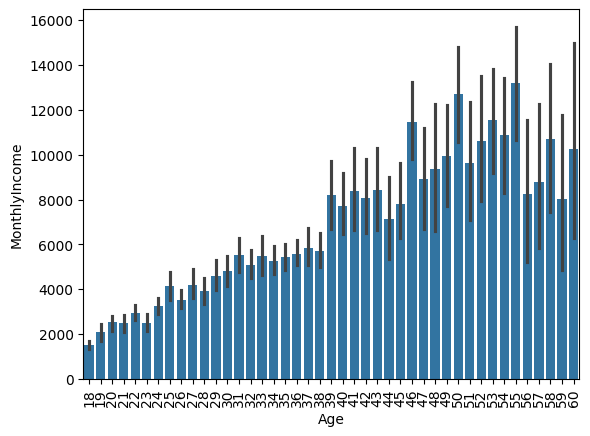

In [3]:
sns.barplot(x= df['Age'],y=df['MonthlyIncome'])
import matplotlib.pyplot as plt
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='Department', ylabel='MonthlyIncome'>

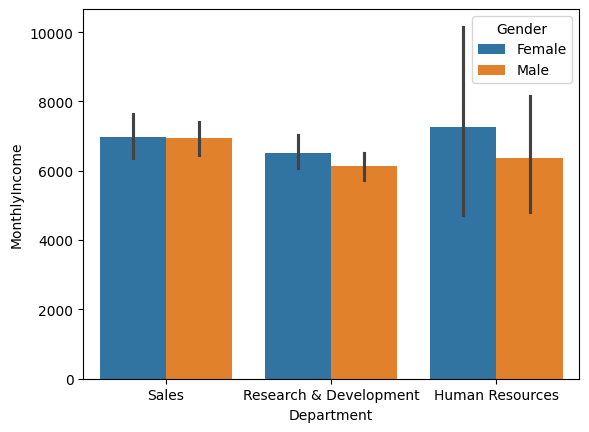

In [4]:
sns.barplot(data = df , x= 'Department',y='MonthlyIncome',hue='Gender')

<Axes: xlabel='OverTime', ylabel='MonthlyIncome'>

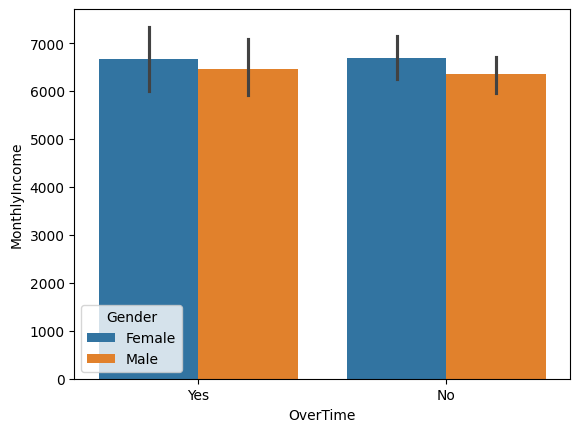

In [5]:
sns.barplot(data = df , x= 'OverTime',y='MonthlyIncome',hue='Gender')

<Axes: >

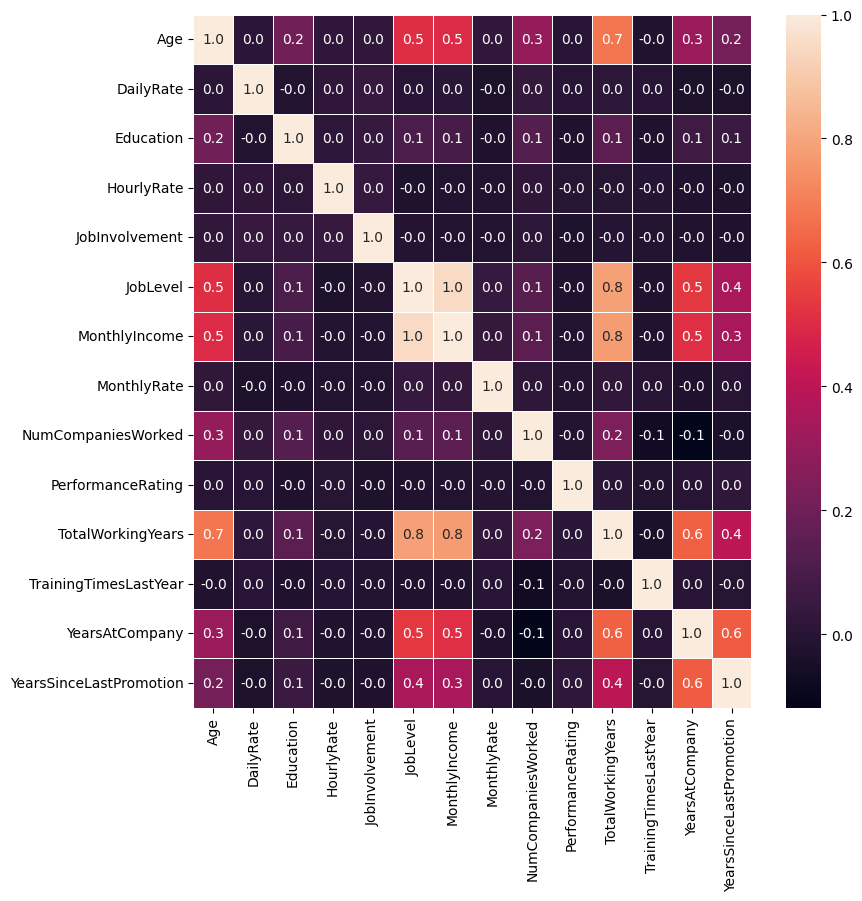

In [6]:
plt.figure(figsize=(9,9))
sns.heatmap(df.corr(numeric_only=True),linewidths=0.5,annot = True,fmt='.1f')

In [7]:
final_df = df.drop(columns=['MonthlyIncome'])
int_col = final_df.select_dtypes(include='int64').columns
col_scale = [col for col in int_col if final_df[col].nunique() > 2]
print(col_scale)
scaler = StandardScaler()
final_df[col_scale] = scaler.fit_transform(final_df[col_scale])
final_df['Salary'] = df['MonthlyIncome']
df.head(3)


['Age', 'DailyRate', 'Education', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'MonthlyRate', 'NumCompaniesWorked', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion']


,Age,Attrition,DailyRate,Department,Education,EducationField,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion
0,41,Yes,1102,Sales,2,Life Sciences,Female,94,3,2,Sales Executive,5993,19479,8,Yes,3,8,0,6,0
1,49,No,279,Research & Development,1,Life Sciences,Male,61,2,2,Research Scientist,5130,24907,1,No,4,10,3,10,1
2,37,Yes,1373,Research & Development,2,Other,Male,92,2,1,Laboratory Technician,2090,2396,6,Yes,3,7,3,0,0


In [8]:
final_df['Attrition'] = final_df['Attrition'].map({'Yes':1,'No':0})
final_df['OverTime'] = final_df['OverTime'].map({'Yes':1,'No':0})
final_df['Gender'] = final_df['Gender'].map({'Male':1,'Female':0})
final_df.head(3)

,Age,Attrition,DailyRate,Department,Education,EducationField,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,MonthlyRate,NumCompaniesWorked,OverTime,PerformanceRating,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,Salary
0,0.446350,1,0.742527,Sales,-0.891688,Life Sciences,0,1.383138,0.379672,-0.057788,Sales Executive,0.726020,2.125136,1,3,-0.421642,-2.171982,-0.164613,-0.679146,5993
1,1.322365,0,-1.297775,Research & Development,-1.868426,Life Sciences,1,-0.240677,-1.026167,-0.057788,Research Scientist,1.488876,-0.678049,0,4,-0.164511,0.155707,0.488508,-0.368715,5130
2,0.008343,1,1.414363,Research & Development,-0.891688,Other,1,1.284725,-1.026167,-0.961486,Laboratory Technician,-1.674841,1.324226,1,3,-0.550208,0.155707,-1.144294,-0.679146,2090


In [9]:
dum = ['Department','EducationField','JobRole']
pri = ['dep','feild','role']
final_df= pd.get_dummies(final_df,columns=dum,prefix=pri,dtype=int,drop_first=True)
final_df

,Age,Attrition,DailyRate,Education,Gender,HourlyRate,JobInvolvement,JobLevel,MonthlyRate,NumCompaniesWorked,...,feild_Other,feild_Technical Degree,role_Human Resources,role_Laboratory Technician,role_Manager,role_Manufacturing Director,role_Research Director,role_Research Scientist,role_Sales Executive,role_Sales Representative
0,0.446350,1,0.742527,-0.891688,0,1.383138,0.379672,-0.057788,0.726020,2.125136,...,0,0,0,0,0,0,0,0,1,0
1,1.322365,0,-1.297775,-1.868426,1,-0.240677,-1.026167,-0.057788,1.488876,-0.678049,...,0,0,0,0,0,0,0,1,0,0
2,0.008343,1,1.414363,-0.891688,1,1.284725,-1.026167,-0.961486,-1.674841,1.324226,...,1,0,0,1,0,0,0,0,0,0
3,-0.429664,0,1.461466,1.061787,0,-0.486709,0.379672,-0.961486,1.243211,-0.678049,...,0,0,0,0,0,0,0,1,0,0
4,-1.086676,0,-0.524295,-1.868426,1,-1.274014,0.379672,-0.961486,0.325900,2.525591,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0,0.202082,-0.891688,1,-1.224807,1.785511,-0.057788,-0.284329,0.523316,...,0,0,0,1,0,0,0,0,0,0
1466,0.227347,0,-0.469754,-1.868426,1,-1.175601,-1.026167,0.845911,1.004010,0.523316,...,0,0,0,0,0,0,0,0,0,0
1467,-1.086676,0,-1.605183,0.085049,1,1.038693,1.785511,-0.057788,-1.284418,-0.678049,...,0,0,0,0,0,1,0,0,0,0
1468,1.322365,0,0.546677,0.085049,1,-0.142264,-1.026167,-0.057788,-0.150393,-0.277594,...,0,0,0,0,0,0,0,0,1,0


In [10]:
x = final_df.drop('Salary',axis=1)
y = final_df['Salary']
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](31,)","[ -23.13, 94.3 , 33.74,...,-369.11, 322.23,-257.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](31,)","['Age','Attrition','DailyRate',...,'role_Research Scientist', 'role_Sales Executive','role_Sales Representative']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5997
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,31
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,31


In [11]:
prid = model.predict(x_test)
r2 = r2_score(y_test,prid)
(r2)*100

93.71543252126231

In [12]:
n = x_test.shape[0]
p = x_test.shape[1]
avj = (1 - ((1-r2)*(n-1)/(n-p-1)))*100
avj

92.97183865927427

here we go we have a great model r2 score 93% 

In [13]:
import joblib
joblib.dump(scaler,'scaller.pkl')
joblib.dump(model,'REG_model.pkl')
joblib.dump(x.columns.tolist(),'columnsl.pkl')

['columnsl.pkl']

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Train R2:", train_r2)
print("Test R2:", test_r2)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("R2 difference (train - test):", train_r2 - test_r2)

cv_scores = cross_val_score(model, x, y, cv=5, scoring="r2")
print("CV R2 mean:", cv_scores.mean())
print("CV R2 std:", cv_scores.std())